In [1]:
from run_si_pipeline import run_spike_interface

SESSION = "kendra_scrappy_0125a_g0"
PROBE_ID = 1

PROTOCOL_FILE = "np_protocol.json"
RAW_DATA_PATH = "/ix1/pmayo/lab_NHPdata"

CUDA available: True
Current device: 0
Device name: NVIDIA A100-PCIE-40GB


In [2]:
run_spike_interface(SESSION, probe_id=PROBE_ID)

[INFO] - Loading faiss with AVX2 support.
[INFO] - Successfully loaded faiss with AVX2 support.


-------------------LOADING RAW RECORDING-------------------
Sampling frequency: 30000.026815642457
Number of channels: 384
Number of segments: 1
Number of samples: 101340654
Duration of recording (min): 56
Data dtype: int16
-------------------PREPROCESSING RECORDING-------------------
Sampling frequency: 30000.026815642457
Number of channels: 383
Number of segments: 1
Number of samples: 2700000
Duration of recording (min): 1
Data dtype: int16
-------------------LOADING MOTION-------------------
-------------------CORRECTING MOTION-------------------
Sampling frequency: 30000.026815642457
Number of channels: 383
Number of segments: 1
Number of samples: 2700000
Duration of recording (min): 1
Data dtype: float64


In [7]:
import numpy as np
from pathlib import Path
from scipy.fft import fft, fftfreq
import matplotlib.pyplot as plt

def characterize_motion(motion_folder):
    motion = np.load(Path(motion_folder) / 'motion.npy')
    time_bins = np.load(Path(motion_folder) / 'time_bins.npy')
    depth_bins = np.load(Path(motion_folder) / 'depth_bins.npy')

    # Mean motion over depth
    mean_motion_timecourse = motion.mean(axis=1)
    print(mean_motion_timecourse)
    print(time_bins.shape)

    # -------- (1) Fast/large motion events ("shake" detection) --------
    motion_deriv = np.diff(mean_motion_timecourse)
    shake_threshold = 10  # µm/s, adjust as needed
    shake_events = np.sum(np.abs(motion_deriv) > shake_threshold)

    # -------- (2) Overall motion score --------
    overall_motion_score = np.linalg.norm(motion)
    print(overall_motion_score)

    # -------- (3) Motion frequency spectrum --------
    dt = np.mean(np.diff(time_bins))
    freqs = fftfreq(len(mean_motion_timecourse), d=dt)
    spectrum = np.abs(fft(mean_motion_timecourse))

    slow_band = (freqs > 0) & (freqs < 0.001)
    jitter_band = (freqs >= 0.001) & (freqs < 0.1)
    shake_band = freqs >= 0.1

    energy_total = np.sum(spectrum)
    energy_ratios = {
        'slow_drift': np.sum(spectrum[slow_band]) / energy_total,
        'jitter': np.sum(spectrum[jitter_band]) / energy_total,
        'shake': np.sum(spectrum[shake_band]) / energy_total
    }

    # -------- (4) Certainty (placeholder) --------
    certainty = "Unavailable — you can add trainer.losses or trainer.history if needed"

    # -------- Save spectrum plot --------
    fig_path = Path(motion_folder) / "motion_frequency_spectrum.png"
    plt.figure(figsize=(10, 4))
    plt.plot(freqs[freqs > 0], spectrum[freqs > 0])
    plt.title("Frequency Spectrum of Mean Motion")
    plt.xlabel("Frequency (Hz)")
    plt.ylabel("Amplitude")
    plt.grid(True)
    plt.tight_layout()
    plt.show()
    #plt.savefig(fig_path)
    #plt.close()

    # -------- Summary --------
    return {
        "shake_events": int(shake_events),
        "overall_motion_score": float(overall_motion_score),
        "energy_ratios": energy_ratios,
        "certainty": certainty,
        "spectrum_plot": str(fig_path)
    }

[-0.727587   -0.90824413 -1.0871452  -1.2019011  -1.2274714  -1.2066548
 -1.0562837  -0.7429837  -0.22674882  0.3368417   0.8169918   1.0903393
  1.1992745   1.2315136   1.299996    1.3911349   1.4670508   1.4953914
  1.4725008   1.4021182   1.3132126   1.0898249   0.73274946  0.15129447
 -0.47502553 -0.9902687  -1.3149157  -1.4493983  -1.4402239  -1.4165456
 -1.365943   -1.1825001  -0.8996375  -0.57918406 -0.2788128  -0.03619806
  0.239761    0.464481    0.7539824   1.00671     1.1386108   1.2156551
  1.2045351   1.0892191   0.9218619   0.7016231   0.3800038  -0.03641001
 -0.46682018 -0.8505331  -1.1545303  -1.4209816  -1.5258062  -1.5516111
 -1.4623652  -1.2660916  -1.097561   -0.9352904  -0.7677969  -0.5586779
 -0.3049811  -0.026032    0.32419288  0.6737819   0.9752204   1.2192204
  1.4294066   1.507253    1.4780947   1.2992694   1.0378138   0.8161973
  0.63176274  0.50213253  0.36819524  0.20115578  0.0418753  -0.1568734
 -0.34815848 -0.4919135  -0.59576154 -0.6855376  -0.7212663  

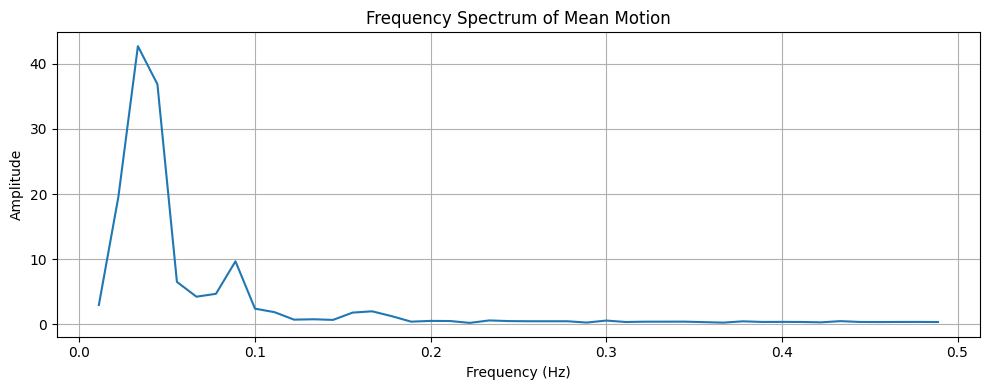

{'shake_events': 0,
 'overall_motion_score': 34.70513916015625,
 'energy_ratios': {'slow_drift': 0.0,
  'jitter': 0.4221889,
  'shake': 0.07750493},
 'certainty': 'Unavailable — you can add trainer.losses or trainer.history if needed',
 'spectrum_plot': '/ix1/pmayo/lab_NHPdata/kendra_scrappy_0125a_g0/kendra_scrappy_0125a_g0_imec1/motion/medicine_tkw30_ndb2/motion_frequency_spectrum.png'}

In [8]:
motion_folder = '/ix1/pmayo/lab_NHPdata/kendra_scrappy_0125a_g0/kendra_scrappy_0125a_g0_imec1/motion/medicine_tkw30_ndb2'

characterize_motion(motion_folder)

In [ ]:
motion_folder = '/ix1/pmayo/lab_NHPdata/kendra_scrappy_0125a_g0/kendra_scrappy_0125a_g0_imec0/motion/medicine_tkw30_ndb2'

characterize_motion(motion_folder)